# Gradient Boosting Method Demonstration In Python
#### Marketing Campaing Response Model
   

## Background: 
The large skin-clinic in the city of “XXX” offers variety of products and services to customers. The marketing campaign was launched for introducing a new product.

The data shows response to the marketing campaign alongwith demographic and transaction data of customers.

The objective is to develop a predictive model which can be implemented for the next campaign

## Dataset Description :

| Column Name     | Description                                                                                  |
|-----------------|----------------------------------------------------------------------------------------------|
| Custid          | Unique Customer Identification Code                                                          |
| Age             | Age Group (1: <32 years, 2: 32–48 years, 3: >48 years)                                      |
| Gender          | Gender of Customer (1: Female, 2: Male)                                                     |
| MS              | Marital Status (1: Not Married, 2: Married)                                                 |
| Response        | Customer Campaign Response (1: Responded, 0: Not Responded)                                 |
| Pre_Month       | Purchase Status in Previous Month (1: Purchased, 2: No Purchase)                            |
| N_Products      | Number of Unique Products Purchased in One Year                                             |
| N_Service       | Number of Unique Services Purchased in One Year                                             |
| BillAmt_1       | Bill Amount (USD) for Purchase Transaction 1                                                |
| BillAmt_2       | Bill Amount (USD) for Purchase Transaction 2                                                |
| BillAmt_3       | Bill Amount (USD) for Purchase Transaction 3                                                |


###  Import Libraries

In [1]:
import pandas as pd  
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import GradientBoostingClassifier

import warnings
warnings.filterwarnings('ignore')

###  Import Data

In [2]:
purchase_data1 = pd.read_csv('Purchase Data 1.csv')
purchase_data2 = pd.read_csv('Purchase Data 2.csv')
response_data = pd.read_csv('Response Data.csv')

#Merging above 3 datasets
masterdata=pd.merge(response_data,purchase_data1,how='left',on = 'Custid')
masterdata=pd.merge(masterdata,purchase_data2,how='left',on = 'Custid')
masterdata.head()

,Custid,Age,Gender,MS,Response,Pre_Month,N_Products,N_Service,BillAmt_1,BillAmt_2,BillAmt_3
0,1,2,1,2,1,2,15,24,12.34,13.26,5.88
1,2,2,2,1,0,1,22,29,18.65,2.12,5.13
2,3,1,1,2,0,1,17,21,7.22,3.31,3.65
3,4,2,1,1,0,2,18,22,6.15,2.95,2.34
4,5,2,2,1,0,1,31,35,20.64,2.67,4.07


In [3]:
masterdata.dtypes

Custid          int64
Age             int64
Gender          int64
MS              int64
Response        int64
Pre_Month       int64
N_Products      int64
N_Service       int64
BillAmt_1     float64
BillAmt_2     float64
BillAmt_3     float64
dtype: object

### Variable Type Conversion: Integer → Category

In [4]:
masterdata['Age'] = masterdata['Age'].astype('category')
masterdata['Gender'] = masterdata['Gender'].astype('category')
masterdata['MS'] = masterdata['MS'].astype('category')
masterdata['Pre_Month'] = masterdata['Pre_Month'].astype('category')

### Estimating Campaign Response Rate : Overall and by Segments


### a. Overall Campaign Response Rate

In [5]:
# Overall response rate
overall_response_rate = masterdata['Response'].mean() * 100
print(f"Overall Campaign Response Rate: {overall_response_rate:.2f}%")

Overall Campaign Response Rate: 13.23%


### Set up Target

In [6]:
X = masterdata.drop(columns=['Response','Custid'])
y = masterdata['Response']

### Create Dummies

In [7]:
X_enc = pd.get_dummies(X, drop_first=True)
X_enc.head()

,N_Products,N_Service,BillAmt_1,BillAmt_2,BillAmt_3,Age_2,Age_3,Gender_2,MS_2,Pre_Month_2
0,15,24,12.34,13.26,5.88,True,False,False,True,True
1,22,29,18.65,2.12,5.13,True,False,True,False,False
2,17,21,7.22,3.31,3.65,False,False,False,True,False
3,18,22,6.15,2.95,2.34,True,False,False,False,True
4,31,35,20.64,2.67,4.07,True,False,True,False,False


###  Split Data Into Train & Test

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


### Build Model

**AdaBoost vs Gradient Boosting (GBM)**

Both **AdaBoost** and **Gradient Boosting** do not build one large complex decision tree. Instead, they create **many small trees sequentially**, where each new tree improves the mistakes of the previous ones to form a strong final model.

The key difference is in **how they correct errors**:

* **AdaBoost** focuses on **misclassified data points** — it gives higher weight to the wrong predictions so the next tree pays more attention to those specific samples.
* **Gradient Boosting (GBM)** focuses on **reducing the overall prediction error (residuals)** mathematically — each new tree tries to minimize the total loss step-by-step rather than only fixing misclassified points.

**In short:**
AdaBoost = *focus on wrong samples*
GBM = *focus on reducing total error*


**n_estimators** → number of boosting stages (same concept as AdaBoost).

**learning_rate** → how strongly each tree corrects previous errors.

##### Note

- GBM usually works well with learning_rate = 0.05–0.1 rather than 1.0.

- Lower learning rate + more trees = more stable model.

In [9]:

gbm = GradientBoostingClassifier(
    n_estimators=200,     # number of trees
    learning_rate=0.1,    # step size shrinkage
    random_state=42
)

gbm.fit(X_train, y_train)

GradientBoostingClassifier(n_estimators=200, random_state=42)

### Check Optimal Threshold

In [10]:
y_prob = gbm.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
j_scores = tpr - fpr
ix = np.argmax(j_scores)

best_threshold = thresholds[ix]
print("Optimal Threshold:", best_threshold)


Optimal Threshold: 0.13379363825959856


### Make Predictions

In [11]:
y_pred = (y_prob >= best_threshold).astype(int)
y_prob = gbm.predict_proba(X_test)[:, 1]

### Inference :
The optimal threshold obtained was 0.133

### Confusion Matrix

In [12]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[848 365]
 [ 37 148]]


### Classification Report

In [13]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.70      0.81      1213
           1       0.29      0.80      0.42       185

    accuracy                           0.71      1398
   macro avg       0.62      0.75      0.62      1398
weighted avg       0.87      0.71      0.76      1398



###  ROC and AUC for Test Data

In [14]:

auc = roc_auc_score(y_test, y_prob)
print(f"Test AUC: {auc:.3f}")


Test AUC: 0.809


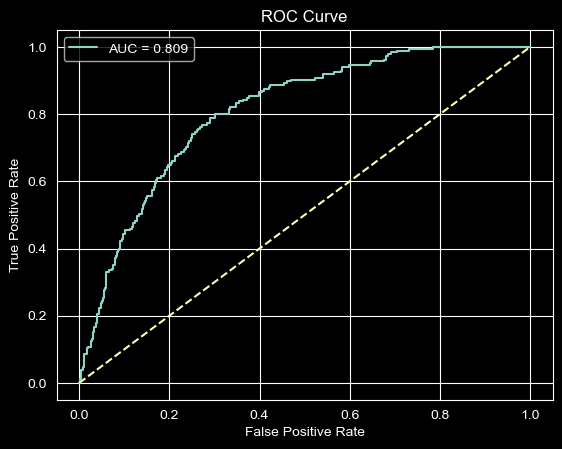

In [15]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc_value = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label='AUC = %0.3f' % roc_auc_value)
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Inference :
An ROC-AUC of 80.9% means the model has good ability to distinguish between the two classes.